In [4]:
!pip install fredapi
!pip install factor-analyzer

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42715 sha256=2d07a26bb3872b47e53b7010441b6d3cac9aa15be50db2c4948aa840b55e0215
  Stored in directory: c:\users\wjack\appdata\local\pip\cache\wheels\87\6e\8f\914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor-analyzer


In [1]:
from fredapi import Fred
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import FactorAnalysis
from factor_analyzer.rotator import Rotator

import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from dotenv import load_dotenv

# Download Data

Blending 2 data sources - economic data from FRED, and S&P 500 returns from Kaggle

In [3]:
# Download latest version
path = kagglehub.dataset_download("rezanematpour/historical-s-and-p-500-gspc-index-data-19272025")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\wjack\.cache\kagglehub\datasets\rezanematpour\historical-s-and-p-500-gspc-index-data-19272025\versions\1


In [4]:
sp500_kaggle = pd.read_csv(os.path.join(path, "SP500.csv"))
#sp500_kaggle.head()

In [5]:
sp500_kaggle["Date"] = pd.to_datetime(sp500_kaggle["Date"])
sp500_kaggle = sp500_kaggle.set_index("Date")

sp500_kaggle_monthly = sp500_kaggle["Close"].resample("ME").last()
sp500_kaggle_returns = np.log(sp500_kaggle_monthly).diff()
sp500_kaggle_returns.name = "sp500_return"

# convert month-end timestamps to month-start timestamps to match your macro df
sp500_kaggle_returns.index = sp500_kaggle_returns.index.to_period("M").to_timestamp()

In [6]:
#df.tail()

In [9]:
load_dotenv()

fred_api_key = os.getenv("FRED_API_KEY")

if fred_api_key is None:
    raise ValueError("FRED_API_KEY not found. Create a .env file.")

In [10]:
fred = Fred(fred_api_key)

In [11]:
sp500_fred = fred.get_series("SP500")
sp500_fred_monthly = sp500_fred.resample("ME").last()
sp500_fred_returns = np.log(sp500_fred_monthly).diff()

sp500_fred_returns.name = "sp500_return"

sp500_fred_returns.index = sp500_fred_returns.index.to_period("M").to_timestamp()

In [12]:
sp500_combined = sp500_kaggle_returns.copy()

sp500_combined.update(sp500_fred_returns)

In [13]:
series = {
    "INDPRO": "industrial_production",
    "PAYEMS": "payrolls",
    "UNRATE": "unemployment_rate",
    "RPI": "real_personal_income",
    #"RETAILSMNSA": "retail_sales",
    "PCE": "personal_consumption",
    #"CPIAUCSL": "cpi",
    "PCEPI": "pce_price_index",
    "FEDFUNDS": "fed_funds",
    #"DGS10": "treasury_10y",
    #"DGS2": "treasury_2y",
    "HOUST": "housing_starts",
    "PERMIT": "building_permits",
    #"BAA10Y": "corporate_spread",
    "BAA": "corporate_yield"
}


df = pd.DataFrame({
    name: fred.get_series(code)
    for code, name in series.items()
})

tenY = fred.get_series("DGS10").resample("ME").mean()
twoY = fred.get_series("DGS2").resample("ME").mean()
yield_curve_spread = fred.get_series("T10Y2Y").resample("ME").mean()

tenY.index = tenY.index.to_period("M").to_timestamp()
twoY.index = twoY.index.to_period("M").to_timestamp()
yield_curve_spread.index = yield_curve_spread.index.to_period("M").to_timestamp()

df["10y_yield"] = tenY
df["2y_yield"] = twoY
df["yield_curve_spread"] = yield_curve_spread

df["corporate_spread"] = df["corporate_yield"] - df["10y_yield"]
df = df.drop(columns=["corporate_yield"])
df = df.drop(columns=["2y_yield"])

df = df.join(sp500_combined, how="left")

df.head()

,industrial_production,payrolls,unemployment_rate,real_personal_income,personal_consumption,pce_price_index,fed_funds,housing_starts,building_permits,10y_yield,yield_curve_spread,corporate_spread,sp500_return
1919-01-01,4.8739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-02-01,4.6585,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-03-01,4.5238,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-04-01,4.6046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1919-05-01,4.6315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Transform Data

Factor analyis takes stationary data - levels like CPI and payrolls need to be transformed into (monthly) growth metrics.

In [14]:
growth_vars = ["industrial_production", "payrolls", "real_personal_income", "personal_consumption", "housing_starts", "building_permits","pce_price_index"]

for v in growth_vars:
    df[v] = np.log(df[v]).diff()

In [15]:
df["diff_10y_yield"] = df["10y_yield"].diff()
df["diff_fed_funds"] = df["fed_funds"].diff()

In [16]:
level_vars = ["fed_funds", "yield_curve_spread", "corporate_spread","unemployment_rate"]

In [17]:
df = df.dropna()
df.sort_index()
df.head()

,industrial_production,payrolls,unemployment_rate,real_personal_income,personal_consumption,pce_price_index,fed_funds,housing_starts,building_permits,10y_yield,yield_curve_spread,corporate_spread,sp500_return,diff_10y_yield,diff_fed_funds
1976-06-01,0.001026,0.000807,7.6,0.001477,0.015730,0.004372,5.48,0.024375,-0.005038,7.861364,0.801364,2.028636,0.040111,-0.033636,0.19
1976-07-01,0.005679,0.002152,7.8,0.006138,0.007947,0.005060,5.31,-0.064940,0.046864,7.831905,0.981905,1.988095,-0.008088,-0.029459,-0.17
1976-08-01,0.006854,0.001972,7.8,0.002828,0.007280,0.005490,5.29,0.101069,0.050128,7.768636,1.137273,1.871364,-0.005137,-0.063268,-0.02
1976-09-01,0.003451,0.002356,7.6,0.000865,0.009283,0.005600,5.25,0.104069,0.123454,7.594286,1.178095,1.805714,0.022389,-0.174351,-0.04
1976-10-01,-0.000304,0.000238,7.7,-0.000320,0.006821,0.005222,5.02,-0.054358,-0.038546,7.411000,1.427000,1.879000,-0.022486,-0.183286,-0.23


Examine correlations

Text(0.5, 1.0, 'Macro Variable Correlations')

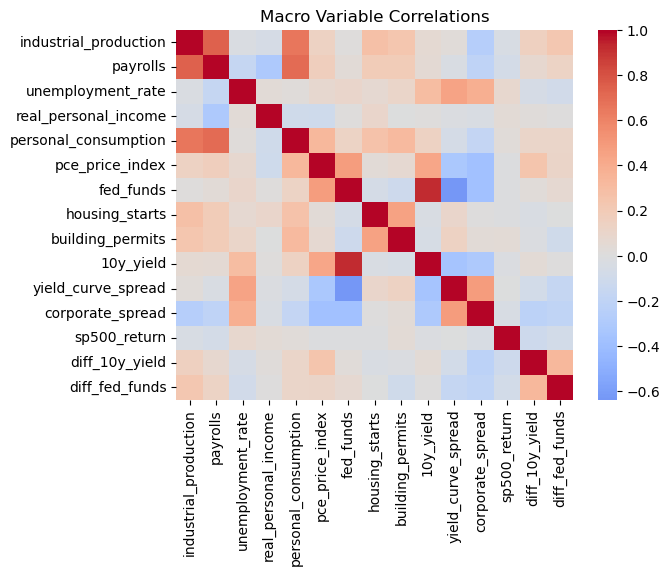

In [18]:
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Macro Variable Correlations")

Standardize data

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [20]:
X = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

In [21]:
#X = X.drop(columns=["sp500_return",	"diff_10y_yield",	"diff_fed_funds", "real_personal_income"])

Some of these variables aren't relevant - they can be dropped them for simplicity, or included with small factor loadings (or add additional factors to try and capture them).

Calculate Eigenvalues and Scree plot

In [22]:
corr_matrix = X.corr()

eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# sort descending
eigenvalues = np.sort(eigenvalues)[::-1]

#eigenvalues

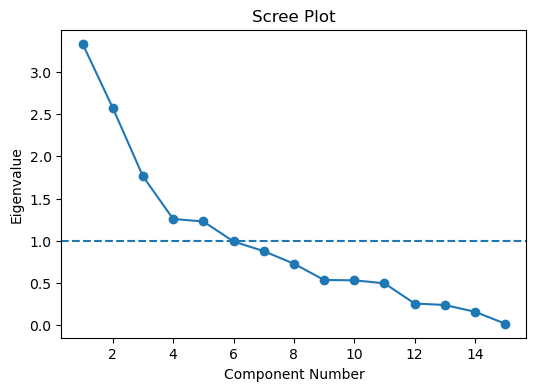

In [23]:
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker="o")

plt.xlabel("Component Number")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.axhline(1, linestyle="--")  # Kaiser rule
plt.show()

Clear drop in eigenvalues, confirming that a few factors explain much of the variability in these ~15 macro indicators. That said, drop-off is not nearly as clear as with our synthetic dataset (prior example).  
Kaiser rule suggests modeling 6 factors, but slope really flattens after 4.

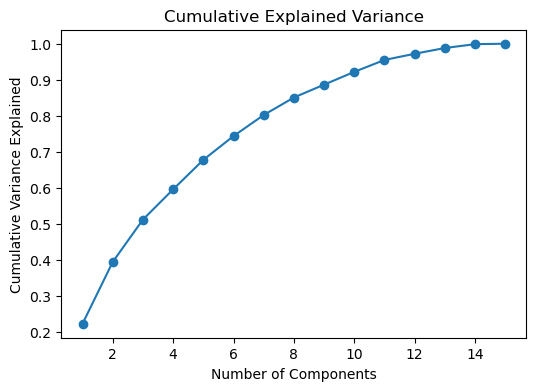

In [24]:
variance_explained = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(variance_explained)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Explained Variance")

#plt.axhline(0.8, linestyle="--", color="gray")  # 80% reference
plt.show()

Fit Factor Analysis model

In [25]:
K = 4

fa = FactorAnalysis(n_components=K)

factor_scores = fa.fit_transform(X)

loadings = pd.DataFrame(
    fa.components_.T,
    index=X.columns,
    columns=[f"Factor{i+1}" for i in range(K)]
)

In [26]:
#loadings

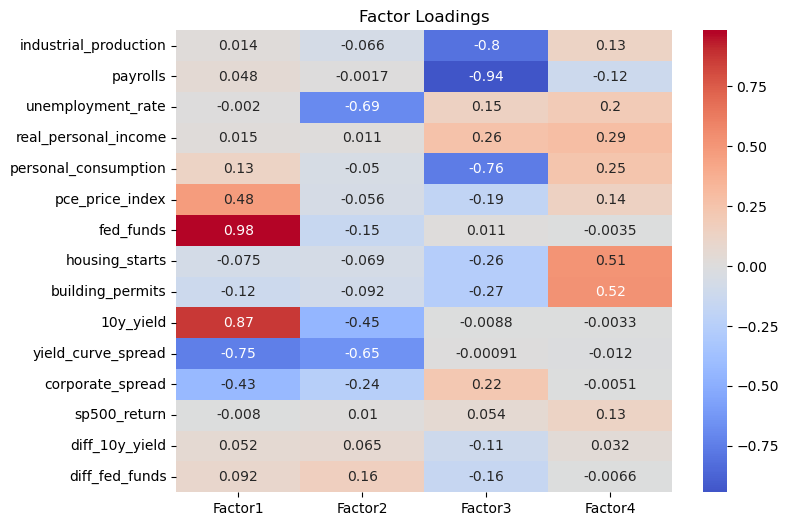

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Factor Loadings")
plt.show()

In [28]:
rotator = Rotator(method="varimax")

rotated_loadings = pd.DataFrame(
    rotator.fit_transform(loadings),
    index=loadings.index,
    columns=loadings.columns
)

In [29]:
#rotated_loadings

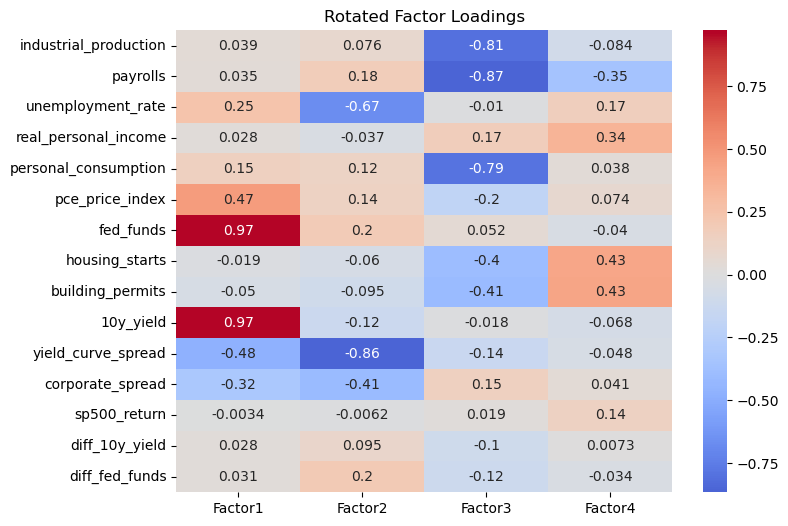

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(rotated_loadings, annot=True, cmap="coolwarm", center=0)
plt.title("Rotated Factor Loadings")
plt.show()

In this example, rotated loadings don't look that different.

Factors won't be perfectly separated conceptually, but looking at factor groupings and making a best effort interpretation...  
  
Factor 1: Interest Rate dominated - fed funds, 10Y most prominent variables by far - likely some redundancy.  

Factor 2: Financial conditions more broadly - Yield curve and corporate spreads both generally associated with recession indicators, unemployment similarly.  

Factor 3: Economic activity / labor strength - Production, total workers, consumption.

Factor 4: Housing.




array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

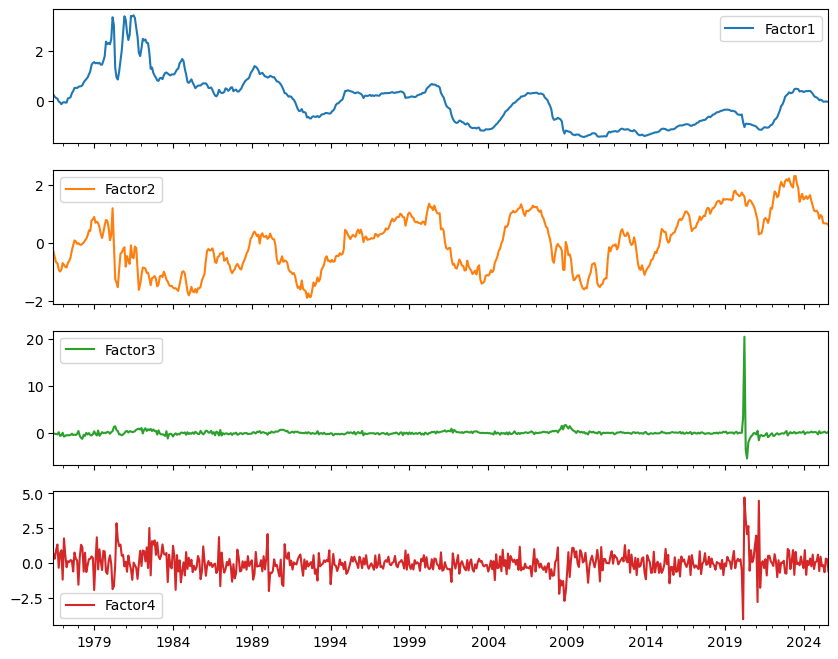

In [31]:
factors = pd.DataFrame(
    factor_scores,
    index=X.index,
    columns=[f"Factor{i+1}" for i in range(K)]
)
factors.plot(subplots=True, figsize=(10,8))

# Testing
Can factors be used to model GDP?  

This isn't really a direct application of Factor Analysis, but is an interesting thought / test.

In [32]:
gdp = fred.get_series("GDPC1")
gdp.index = pd.to_datetime(gdp.index)

gdp.head()

1947-01-01    2182.681
1947-04-01    2176.892
1947-07-01    2172.432
1947-10-01    2206.452
1948-01-01    2239.682
dtype: float64

In [33]:
gdp_growth = np.log(gdp).diff()
gdp_growth.name = "gdp_growth"

In [34]:
factors_q = factors.resample("QE").mean()

In [35]:
factors_q.index = factors_q.index.to_period("Q")
gdp_growth.index = gdp_growth.index.to_period("Q")

In [36]:
df_compare = pd.concat([factors_q, gdp_growth], axis=1).dropna()

In [37]:
df_compare.head()

,Factor1,Factor2,Factor3,Factor4,gdp_growth
1976Q2,0.250574,-0.307351,-0.140419,0.647279,0.007307
1976Q3,0.127549,-0.627379,-0.279367,0.857506,0.005459
1976Q4,-0.067444,-0.948207,-0.364702,0.432352,0.007200
1977Q1,-0.057214,-0.763461,-0.494048,0.385886,0.011793
1977Q2,0.052369,-0.721635,-0.520919,-0.023467,0.019233


In [38]:
df_compare.corr()["gdp_growth"].sort_values(ascending=False)

gdp_growth    1.000000
Factor1       0.040032
Factor2      -0.021193
Factor4      -0.087812
Factor3      -0.839067
Name: gdp_growth, dtype: float64

In [39]:
X_reg = df_compare[[f"Factor{i+1}" for i in range(K)]]
y_reg = df_compare["gdp_growth"]

In [40]:
X_reg = sm.add_constant(X_reg)

model = sm.OLS(y_reg, X_reg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             gdp_growth   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.703
Method:                 Least Squares   F-statistic:                     117.3
Date:                Mon, 06 Jul 2026   Prob (F-statistic):           1.47e-50
Time:                        16:43:20   Log-Likelihood:                 739.89
No. Observations:                 198   AIC:                            -1470.
Df Residuals:                     193   BIC:                            -1453.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0067      0.000     16.229      0.0

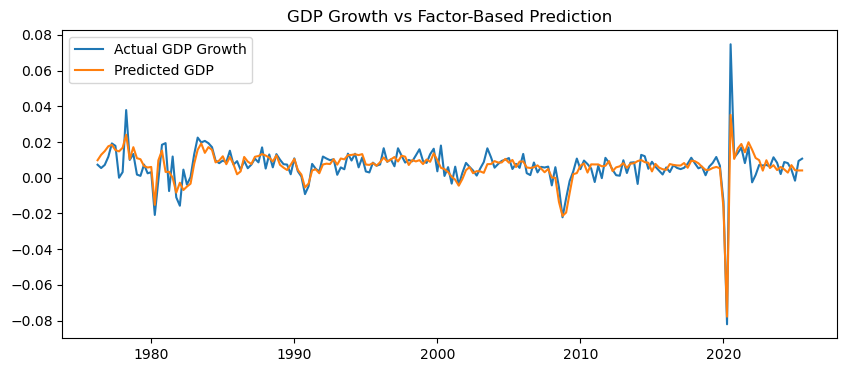

In [41]:
df_compare["gdp_pred"] = model.predict(X_reg)
plt.figure(figsize=(10,4))

plt.plot(df_compare.index.to_timestamp(), df_compare["gdp_growth"], label="Actual GDP Growth")
plt.plot(df_compare.index.to_timestamp(), df_compare["gdp_pred"], label="Predicted GDP")

plt.legend()
plt.title("GDP Growth vs Factor-Based Prediction")

plt.show()

In [42]:
results = []

for K in range(1, 9):

    fa = FactorAnalysis(n_components=K)
    factor_scores = fa.fit_transform(X)

    factors = pd.DataFrame(
        factor_scores,
        index=X.index,
        columns=[f"Factor{i+1}" for i in range(K)]
    )

    factors_q = factors.resample("QE").mean()

    gdp_q = gdp_growth.copy()

    # Ensure quarterly alignment
    if not isinstance(factors_q.index, pd.PeriodIndex):
        factors_q.index = factors_q.index.to_period("Q")

    if not isinstance(gdp_q.index, pd.PeriodIndex):
        gdp_q.index = gdp_q.index.to_period("Q")

    df_compare = pd.concat([factors_q, gdp_q], axis=1).dropna()

    X_reg = df_compare[[f"Factor{i+1}" for i in range(K)]]
    X_reg = sm.add_constant(X_reg)
    y_reg = df_compare["gdp_growth"]

    model = sm.OLS(y_reg, X_reg).fit()

    y_pred = model.predict(X_reg)

    rmse = np.sqrt(mean_squared_error(y_reg, y_pred))
    mape = mean_absolute_percentage_error(y_reg, y_pred)

    results.append((K, rmse, mape))

results_df = pd.DataFrame(results, columns=["K", "RMSE", "MAPE"])
#results_df

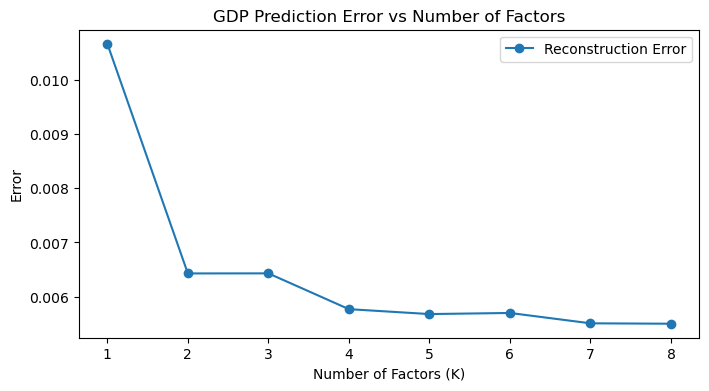

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(results_df["K"], results_df["RMSE"], marker="o", label="Reconstruction Error")

plt.xlabel("Number of Factors (K)")
plt.ylabel("Error")
plt.title("GDP Prediction Error vs Number of Factors")

plt.legend()
plt.show()